### Import libraries


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Load MovieLens Datasets

In [3]:
path  = Path.cwd() / "ml-32m"

In [4]:
ratings = pd.read_csv(path / "ratings.csv")

In [5]:
movies = pd.read_csv(path / "movies.csv")

In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
# Check datasets shape
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Movies: (87585, 3)
Ratings: (32000204, 4)


In [10]:

# Check rating distribution
user_rating_counts = ratings['userId'].value_counts()
print("\nUser rating statistics:")
print(f"Min ratings per user: {user_rating_counts.min()}")
print(f"Max ratings per user: {user_rating_counts.max()}")
print(f"Mean ratings per user: {user_rating_counts.mean():.1f}")
print(f"Median ratings per user: {user_rating_counts.median()}")

# Top users
print("\nTop 10 most active users:")
print(user_rating_counts.head(10))


User rating statistics:
Min ratings per user: 20
Max ratings per user: 33332
Mean ratings per user: 159.2
Median ratings per user: 73.0

Top 10 most active users:
userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
Name: count, dtype: int64


In [9]:
n_rating = len(ratings)
n_user = ratings['userId'].nunique()
n_movie = ratings['movieId'].nunique()
print("Number of ratings:", n_rating)
print("Number of users:", n_user)
print("Number of movies:", n_movie)

Number of ratings: 32000204
Number of users: 200948
Number of movies: 84432


## Data Cleaning

In [10]:
movies['genres'].value_counts()

genres
Drama                                                      12443
Documentary                                                 8132
Comedy                                                      7761
(no genres listed)                                          7080
Comedy|Drama                                                3245
                                                           ...  
Action|Animation|Fantasy|War                                   1
Action|Documentary|Drama|Horror|Mystery|Sci-Fi|Thriller        1
Action|Drama|Fantasy|Horror|Thriller                           1
Action|Animation|Children|Comedy|Crime                         1
Animation|Children|Comedy|Fantasy|Romance                      1
Name: count, Length: 1798, dtype: int64

In [12]:
# Drop movies without genres
movies_filtered = movies.drop(movies[movies.genres=='(no genres listed)'].index)

In [13]:
movies_filtered.to_csv("movies_filtered.csv", index=False)

In [14]:
user_participation = ratings['userId'].value_counts()
threshold = 500

active_users = user_participation[user_participation >= threshold].index
print(active_users.unique().shape[0], "active users with at least", threshold, "ratings")
ratings_filtered = ratings[ratings['userId'].isin(active_users)]

print("Old number of rows in ratings:", ratings.shape[0])
print("Number of rows in filtered ratings:", ratings_filtered.shape[0])

12603 active users with at least 500 ratings
Old number of rows in ratings: 32000204
Number of rows in filtered ratings: 11928570


In [15]:
ratings_filtered.to_csv("ratings_filtered.csv", index=False)

In [13]:
# Merge the filtered movies and ratings
movies_ratings = pd.merge(movies_filtered, ratings_filtered, on='movieId')

In [14]:
movies_ratings.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,28,4.0,961438127
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,188,4.0,1103751789
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,265,5.0,1607904458
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,354,4.0,980520710
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,360,3.0,1577768517


In [15]:
movies_ratings.shape

(5812407, 6)

In [16]:
ratings_map= {5.5:5, 4.5: 4, 3.5:3, 2.5:2, 1.5:1, 0.5:1}
for index, row in movies_ratings.iterrows():
  if row['rating'] in ratings_map:
    movies_ratings.loc[index, 'rating'] = ratings_map[row['rating']]


In [17]:
movies_ratings['rating'] = movies_ratings['rating'].astype(int)

In [18]:
movies_ratings.dtypes

movieId       int64
title        object
genres       object
userId        int64
rating        int64
timestamp     int64
dtype: object

### Exploratory Data Analysis

In [19]:
all_genres = movies_filtered['genres'].str.split('|').explode()
print(all_genres)

0          Adventure
0          Animation
0           Children
0             Comedy
0            Fantasy
            ...     
87582          Drama
87583          Drama
87584         Action
87584      Adventure
87584    Documentary
Name: genres, Length: 147090, dtype: object


In [20]:
genres_count = all_genres.value_counts()
print(genres_count)

genres
Drama          34175
Comedy         23124
Thriller       11823
Romance        10369
Action          9668
Documentary     9363
Horror          8654
Crime           6976
Adventure       5402
Sci-Fi          4907
Animation       4617
Children        4520
Mystery         4013
Fantasy         3851
War             2325
Western         1696
Musical         1059
Film-Noir        353
IMAX             195
Name: count, dtype: int64


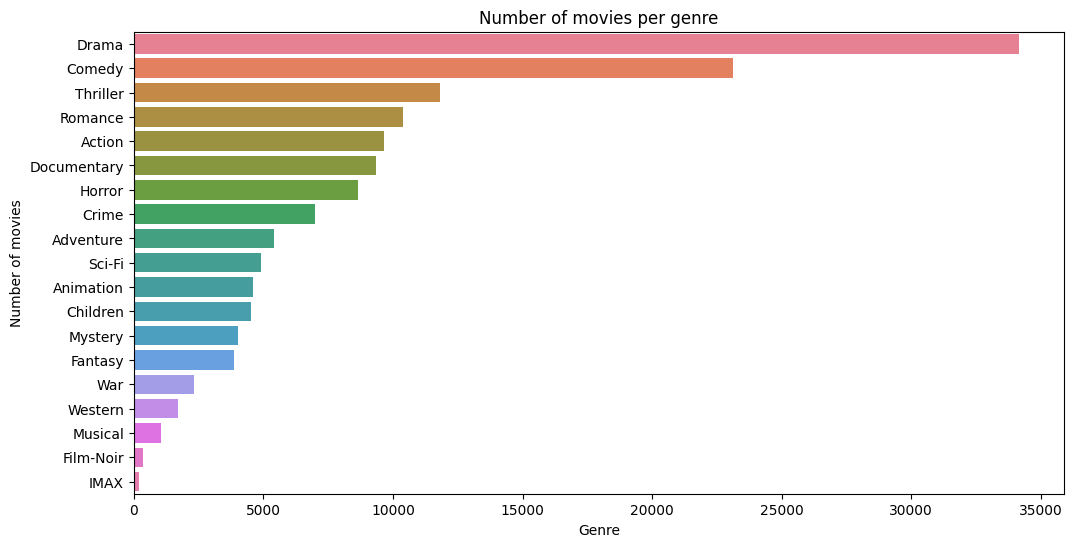

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(x=genres_count.values , y=genres_count.index ,hue=genres_count.index)
plt.title('Number of movies per genre')
plt.xlabel('Genre')
plt.ylabel('Number of movies')
plt.show()

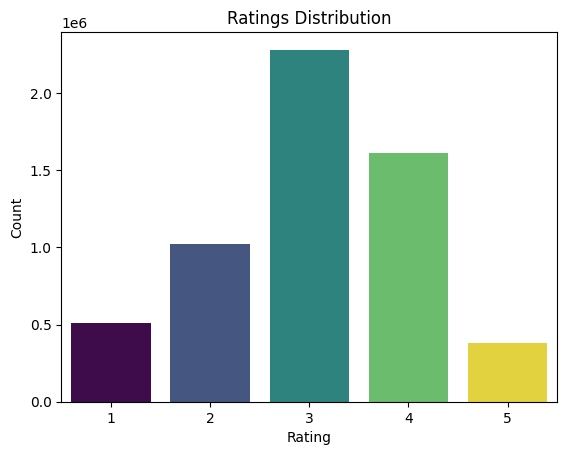

In [22]:
sns.countplot(data=movies_ratings, x='rating',palette='viridis',hue='rating',legend=False)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [23]:
movies_ratings.to_csv('movies_ratings.csv', index=False)